<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab1/blob/main/task_2_TitanicSurvival_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Імпорт потрібних бібліотек.**

На початку роботи підключаємо бібліотеки для аналізу даних. `pandas` — основний інструмент для роботи з табличними даними, `matplotlib` і `seaborn` використовуються для побудови графіків і візуалізації результатів аналізу.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Завантаження набору даних катастрофи «Титанік» за URL-адресою.**

За допомогою функції `read_csv` завантажуємо датасет з інтернет-джерела. Набір даних містить інформацію про пасажирів: ім'я, стать, вік, клас каюти та чи вижив пасажир. Перевірка виконання відбувається через блок `try-except`.

In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv'

try:
    titanic_df = pd.read_csv(url)
    print("Data was loaded successfully:")
    display(titanic_df.head())
except Exception as e:
    print(f"Error on load: {e}")

Data was loaded successfully:


,rownames,survived,sex,age,passengerClass
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st


**Перевірка розмірності набору даних.**

Метод `shape` показує кількість рядків і стовпців у таблиці. У датасеті Титаніка понад 1300 рядків, кожен з яких відповідає одному пасажиру.

In [9]:
titanic_df.shape

(1309, 5)

**Огляд загальної інформації про дані.**

Метод `info()` показує типи даних кожного стовпця, кількість непорожніх значень і використання пам'яті. Важливо звернути увагу на колонку `age`: лише 1046 з 1309 рядків містять вік, решта позначені як NaN (відсутні значення).

In [3]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rownames        1309 non-null   object 
 1   survived        1309 non-null   object 
 2   sex             1309 non-null   object 
 3   age             1046 non-null   float64
 4   passengerClass  1309 non-null   object 
dtypes: float64(1), object(4)
memory usage: 51.3+ KB


**Перегляд перших рядків набору даних.**

Метод `head()` показує перші п'ять рядків таблиці. За замовчуванням виводиться п'ять рядків, але це число можна змінити аргументом методу.

In [4]:
titanic_df.head()

,rownames,survived,sex,age,passengerClass
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st


**Перегляд останніх рядків набору даних.**

Метод `tail()` показує останні п'ять рядків. У рядку 1305 видно значення NaN у колонці `age` — це позначення відсутнього значення в pandas.

In [5]:
titanic_df.tail()

,rownames,survived,sex,age,passengerClass
1304,"Zabour, Miss. Hileni",no,female,14.5,3rd
1305,"Zabour, Miss. Thamine",no,female,NaN,3rd
1306,"Zakarian, Mr. Mapriededer",no,male,26.5,3rd
1307,"Zakarian, Mr. Ortin",no,male,27.0,3rd
1308,"Zimmerman, Mr. Leo",no,male,29.0,3rd


**Налаштування назв стовпців.**

Замінюємо назву першого стовпця `rownames` на `name` і скорочуємо `passengerClass` до `class`. Це робить назви зручнішими для подальшої роботи з даними.

In [6]:
titanic_df.columns = ['name', 'survived', 'sex', 'age', 'class']
titanic_df.head()

,name,survived,sex,age,class
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st


**Наймолодший пасажир.**

Визначаємо наймолодшого пасажира за допомогою фільтрації за мінімальним значенням віку. Використовуємо порівняння з `age.min()`, оскільки може бути кілька пасажирів з однаковим мінімальним віком. Pandas автоматично ігнорує NaN при обчисленнях.

In [32]:
titanic_df[titanic_df['age'] == titanic_df['age'].min()] # саме так бо раптом їх кілька

,name,survived,sex,age,class
763,"Dean, Miss. Elizabeth Gladys M",yes,female,0.1667,3rd


**Найстаріший пасажир.**

Аналогічно до пошуку наймолодшого, фільтруємо рядки за максимальним значенням віку.

In [14]:
titanic_df[titanic_df['age'] == titanic_df['age'].max()]

,name,survived,sex,age,class
14,"Barkworth, Mr. Algernon Henry W",yes,male,80.0,1st


**Середній вік пасажирів.**

Метод `mean()` обчислює середнє арифметичне значення віку. Враховуються лише рядки з відомим віком; відсутні значення (NaN) пропускаються.

In [46]:
titanic_df['age'].mean()

np.float64(29.881134512434034)

**Статистика по пасажирах, які вижили.**

Створюємо підмножину даних лише з тими пасажирами, у яких `survived == 'yes'`. Це дозволяє аналізувати характеристики тих, хто пережив катастрофу.

In [19]:
survived = titanic_df[titanic_df['survived'] == 'yes']
survived

,name,survived,sex,age,class
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
5,"Anderson, Mr. Harry",yes,male,48.0000,1st
6,"Andrews, Miss. Kornelia Theodos",yes,female,63.0000,1st
8,"Appleton, Mrs. Edward Dale (Cha",yes,female,53.0000,1st
...,...,...,...,...,...
1261,"Turkula, Mrs. (Hedwig)",yes,female,63.0000,3rd
1277,"Vartanian, Mr. David",yes,male,22.0000,3rd
1286,"Whabee, Mrs. George Joseph (Sha",yes,female,38.0000,3rd
1290,"Wilkes, Mrs. James (Ellen Needs",yes,female,47.0000,3rd


**Описова статистика для виживших пасажирів.**

Метод `describe()` показує основні статистичні показники: кількість, середнє, стандартне відхилення, мінімум, квартилі та максимум

In [20]:
survived.describe()

,age
count,427.000000
mean,28.918228
std,15.061481
min,0.166700
25%,20.000000
50%,28.000000
75%,38.000000
max,80.000000


**Відбір жінок з кают 1-го класу.**

Фільтруємо датафрейм за умовами: стать жінка (`sex == 'female'`) і клас 1-й (`class == '1st'`). Отримуємо підмножину пасажирок першого класу для подальшого аналізу.

In [28]:
women_1st_class = titanic_df[(titanic_df['sex'] == 'female') & (titanic_df['class'] == '1st')].copy()
women_1st_class

,name,survived,sex,age,class
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0,1st
6,"Andrews, Miss. Kornelia Theodos",yes,female,63.0,1st
8,"Appleton, Mrs. Edward Dale (Cha",yes,female,53.0,1st
...,...,...,...,...,...
311,"Wick, Mrs. George Dennick (Mary",yes,female,45.0,1st
314,"Widener, Mrs. George Dunton (El",yes,female,50.0,1st
315,"Willard, Miss. Constance",yes,female,21.0,1st
319,"Wilson, Miss. Helen Alice",yes,female,31.0,1st


**Сортування жінок 1-го класу за віком.**

Сортуємо відфільтровану таблицю за зростанням віку, щоб зручно знайти наймолодшу та найстаршу. Параметр `inplace=True` змінює сам датафрейм без створення копії.

In [25]:
women_1st_class.sort_values(by='age')

,name,survived,sex,age,class
2,"Allison, Miss. Helen Loraine",no,female,2.0,1st
55,"Carter, Miss. Lucile Polk",yes,female,14.0,1st
193,"Madill, Miss. Georgette Alexand",yes,female,15.0,1st
159,"Hippach, Miss. Jean Gertrude",yes,female,16.0,1st
195,"Maioni, Miss. Roberta",yes,female,16.0,1st
...,...,...,...,...,...
176,"Kenyon, Mrs. Frederick R (Mario",yes,female,NaN,1st
204,"Meyer, Mrs. Edgar Joseph (Leila",yes,female,NaN,1st
277,"Spencer, Mrs. William Augustus",yes,female,NaN,1st
293,"Taylor, Mrs. Elmer Zebley (Juli",yes,female,NaN,1st


In [29]:
women_1st_class.sort_values(by='age', inplace=True)

**Наймолодша жінка серед пасажирок 1-го класу.**

Застосовуємо фільтрацію за мінімальним віком у підмножині `women_1st_class`, оскільки таких пасажирок може бути кілька.

In [35]:
women_1st_class[women_1st_class['age'] == women_1st_class['age'].min()]

,name,survived,sex,age,class
2,"Allison, Miss. Helen Loraine",no,female,2.0,1st


**Найстаріша жінка серед пасажирок 1-го класу.**

Аналогічно знаходимо пасажирку з максимальним віком серед жінок першого класу.

In [36]:
women_1st_class[women_1st_class['age'] == women_1st_class['age'].max()]

,name,survived,sex,age,class
61,"Cavendish, Mrs. Tyrell William",yes,female,76.0,1st


**Кількість виживших серед жінок 1-го класу.**

Підраховуємо, скільки пасажирок першого класу пережили катастрофу. Фільтруємо `women_1st_class` за умовою `survived == 'yes'` і обчислюємо кількість рядків.

In [ ]:
women_1st_class_survived = women_1st_class[women_1st_class['survived'] == 'yes']

**Гістограма розподілу віку пасажирів.**

Візуалізація допомагає краще зрозуміти дані. За допомогою `seaborn.histplot` будуємо гістограму розподілу вікових груп. Параметр `kde=True` додає криву щільності розподілу. Гістограма наочно показує, у яких вікових діапазонах була найбільша кількість пасажирів.

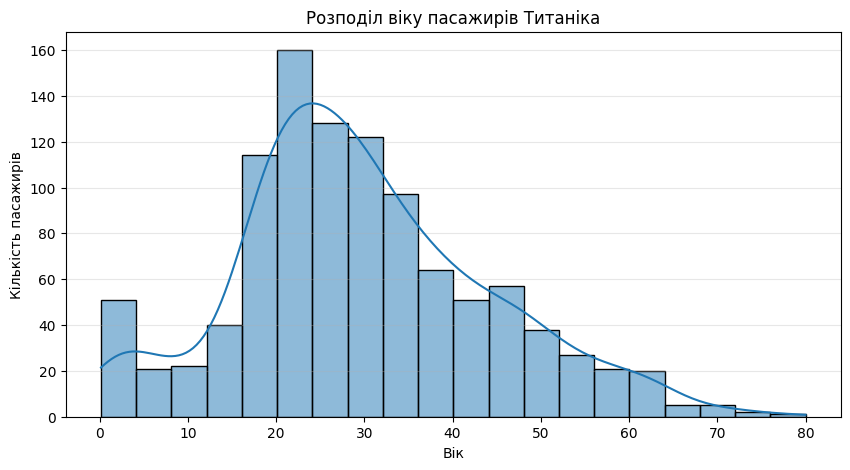

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=titanic_df,
    x='age',
    bins=20,
    kde=True
)

plt.title('Розподіл віку пасажирів Титаніка')
plt.xlabel('Вік')
plt.ylabel('Кількість пасажирів')
plt.grid(axis='y', alpha=0.3)
plt.show()